In [1]:
import pandas as pd
import os
from tcranno import *

In [6]:
samples = pd.read_pickle("/mnt/d/TCRMI/results/covid/samples.pickle")

In [3]:
model = model_predict.load_encoder()
DB, DB_VDJ, AO_map = core_analysis.load_DB(ref_DB='IEDB')

In [7]:
for key, df in samples.items():
    df = df.reset_index()
    newdf = df[['cdr3B', 'barcode']]
    newdf = newdf.drop_duplicates(subset='cdr3B')
    newdf.to_csv(f'/mnt/d/TCRMI/results/covid/tcranno/{key}.tsv', sep='\t', index=False)
    tcr2tcr_outfile = os.path.join('/mnt/d/TCRMI/results/covid/tcranno/tcrmatch', key)
    core_analysis.tcr2tcr(f'/mnt/d/TCRMI/results/covid/tcranno/{key}.tsv', tcr2tcr_outfile, model, DB,DB_VDJ,AO_map,
                          header=True,
                          cdr3_aa_col=0,frequency=False,frequency_col=None,count=False,count_col=None, 
                          sep='\t', k=1, thread=-1)

VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finished
No. of CPUs available: 8
VJ_map loading finis

In [8]:
def parse_epitope_info(epitope_string):
    """
    Helper function to parse epitope information string
    """
    parsed_data = []
    
    if pd.isna(epitope_string):
        return parsed_data
    
    # Split multiple epitopes
    epitope_entries = epitope_string.split('; ')
    
    for entry in epitope_entries:
        if '[' in entry and '->' in entry:
            epitope = entry.split(' [')[0].strip()
            antigen_organism = entry.split(' [')[1].rstrip(']')
            
            if '->' in antigen_organism:
                antigen, organism = antigen_organism.split('->', 1)
                parsed_data.append({
                    'epitope': epitope.strip(),
                    'antigen': antigen.strip(),
                    'organism': organism.strip()
                })
    
    return parsed_data

In [1]:
import glob
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from monte.mcci_selector import MCCISelector
from monte.mcci_explainability import MCCIExplainability
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [22]:
 # Symptom mapping based on patient IDs
symptom_mapping = {
    # Asymptomatic
    "COV_144": "AS", "COV_146": "AS", "COV_147": "AS", "COV_154": "AS", "COV_155": "AS",
    
    # Moderate
    "COV_156": "moderate", "COV_157": "moderate", "COV_48": "moderate", "COV_072": "moderate", 
    "COV_074": "moderate", "COV_76": "moderate", "COV_086": "moderate", "COV_87": "moderate", 
    "COV_089": "moderate", "COV_91": "moderate", "COV_098": "moderate", "COV_101": "moderate", 
    "COV_102": "moderate",
    
    # Severe
    "COV_007": "severe", "COV_009": "severe", "COV_011": "severe", "COV_012": "severe", 
    "COV_013": "severe", "COV_016": "severe", "COV_021": "severe", "COV_029": "severe", 
    "COV_047": "severe", "COV_057": "severe", "COV_077": "severe", "COV_078": "severe",
    
    # SR (Severe Recovery)
    "COV_158": "SR", "COV_159": "SR", "COV_161": "SR", "COV_163": "SR", "COV_037": "SR", 
    "COV_045": "SR", "COV_055": "SR", "COV_119": "SR", "COV_126": "SR", "COV_164": "SR", 
    "COV_165": "SR", "COV_166": "SR"
}

In [11]:
metadata = pd.read_csv("/mnt/d/TCRdataset/covid_GSE196456/metadata.csv")
metadata = metadata.dropna(subset=['barcode','TRAV','TRBV','TRAJ','TRBJ','cdr3A','cdr3B'])
metadata['patient_status'] = metadata.Patient.str.cat(metadata.Age_status)
metadata = metadata[['patient_status','ICU']]
symptom_mapping = {}
for patient in metadata['patient_status'].unique():
    symptom_mapping[patient] = metadata[metadata['patient_status'] == patient]['ICU'].values[0]

In [23]:
def read_and_process_tcr_files(directory_path, symptom_mapping):
    """
    Read all TSV files from the specified directory and create a consolidated DataFrame
    
    Parameters:
    directory_path: str - Path to the directory containing TSV files
    
    Returns:
    pandas.DataFrame - Consolidated data with columns: CDR3_sequence, Matched_Epitope, 
                      Matched_Antigen, Matched_Organism, Symptom
    """
    
    # Get all TSV files in the directory
    tsv_files = glob.glob(os.path.join(directory_path, "*.tsv"))
    
    if not tsv_files:
        print(f"No TSV files found in {directory_path}")
        return pd.DataFrame()
    
    all_data = []
    
    for file_path in tsv_files:
        try:
            # Extract patient ID from filename
            filename = os.path.basename(file_path)
            if 'Adult' in filename:
                patient_id_match = re.search(r'(COV_.*?)_tcr2', filename)
            elif 'Kid' in filename:
                patient_id_match =re.search(r'(COV_.*?)_tcr2', filename)
            else:
                patient_id_match = re.search(r'(COV_\d+)', filename)
                
            patient_id = patient_id_match.group(1)
            if not patient_id_match:
                print(f"Could not extract patient ID from {filename}")
                continue
                    
            symptom = symptom_mapping.get(patient_id, "Unknown")
            
            # Read the TSV file, skipping comment lines
            df = pd.read_csv(file_path, sep='\t', comment='#')
            
            # Create a dictionary to store input CDR3 sequences by their base index
            input_sequences = {}
            
            # First pass: collect all input sequences
            for _, row in df.iterrows():
                if row['Rank'] == 'Input':
                    base_index = str(row['Index'])
                    input_sequences[base_index] = row['CDR3_sequence']
            
            # Second pass: process matched sequences
            for _, row in df.iterrows():
                if row['Rank'] in [1, '1', 'Complete_Match']:
                    # Extract base index from compound index (e.g., "1-1" -> "1", "8-0" -> "8")
                    index_str = str(row['Index'])
                    if '-' in index_str:
                        base_index = index_str.split('-')[0]
                    else:
                        base_index = index_str
                    
                    # Find corresponding input sequence
                    if base_index not in input_sequences:
                        continue
                        
                    input_cdr3 = input_sequences[base_index]
                    
                    # Skip rows without epitope matches
                    epitope_col = 'Matched_Epitope(s) [Matched_Antigen->Matched_Organism]'
                    if epitope_col not in row or pd.isna(row[epitope_col]):
                        continue
                    
                    epitope_info = row[epitope_col]
                    
                    # Parse multiple epitope entries separated by '; '
                    epitope_entries = epitope_info.split('; ')
                    
                    for entry in epitope_entries:
                        # Parse format: EPITOPE [ANTIGEN->ORGANISM]
                        if '[' in entry and '->' in entry:
                            epitope = entry.split(' [')[0].strip()
                            antigen_organism = entry.split(' [')[1].rstrip(']')
                            
                            if '->' in antigen_organism:
                                antigen, organism = antigen_organism.split('->', 1)
                                antigen = antigen.strip()
                                organism = organism.strip()
                                
                                # Add to data list - using INPUT CDR3 with MATCHED epitope info
                                all_data.append({
                                    'Patient_ID': patient_id,
                                    'CDR3_sequence': input_cdr3,  # Use INPUT CDR3 sequence
                                    'Matched_CDR3': row['CDR3_sequence'],  # Store matched CDR3 for reference
                                    'Matched_Epitope': epitope,
                                    'Matched_Antigen': antigen,
                                    'Matched_Organism': organism,
                                    'Symptom': symptom,
                                    'Weighted_Score': row.get('Weighted_Score', None),
                                    'Match_Type': row['Rank']
                                })
                        
        except Exception as e:
            print(f"Error processing file {file_path}: {str(e)}")
            continue
    
    # Create DataFrame
    if all_data:
        result_df = pd.DataFrame(all_data)
        print(f"Successfully processed {len(tsv_files)} files")
        print(f"Total records: {len(result_df)}")
        print(f"Unique patients: {result_df['Patient_ID'].nunique()}")
        print(f"Unique input CDR3 sequences: {result_df['CDR3_sequence'].nunique()}")
        print(f"Unique matched CDR3 sequences: {result_df['Matched_CDR3'].nunique()}")
        print(f"Match types: {result_df['Match_Type'].value_counts().to_dict()}")
        print(f"Symptom distribution:")
        print(result_df['Symptom'].value_counts())
        return result_df
    else:
        print("No data found in any files")
        return pd.DataFrame()


changed to for antigen because a TCR could target to many epitopes of the same antigen

In [24]:
directory_path = "/mnt/d/TCRMI/results/covid/tcranno/tcrmatch"
result_df = read_and_process_tcr_files(directory_path, symptom_mapping)
result_df = result_df.drop_duplicates(subset=['Patient_ID', 'CDR3_sequence', 'Matched_CDR3', 
                                              'Matched_Antigen', 'Matched_Organism'])
result_df = result_df[result_df['Matched_Organism']=='SARS-CoV2']

Error processing file /mnt/d/TCRMI/results/covid/tcranno/tcrmatch/NC_05_tcr2tcr_output.tsv: 'NoneType' object has no attribute 'group'
Error processing file /mnt/d/TCRMI/results/covid/tcranno/tcrmatch/NC_07_tcr2tcr_output.tsv: 'NoneType' object has no attribute 'group'
Error processing file /mnt/d/TCRMI/results/covid/tcranno/tcrmatch/NC_1_tcr2tcr_output.tsv: 'NoneType' object has no attribute 'group'
Error processing file /mnt/d/TCRMI/results/covid/tcranno/tcrmatch/NC_20_tcr2tcr_output.tsv: 'NoneType' object has no attribute 'group'
Error processing file /mnt/d/TCRMI/results/covid/tcranno/tcrmatch/NC_21_tcr2tcr_output.tsv: 'NoneType' object has no attribute 'group'
Error processing file /mnt/d/TCRMI/results/covid/tcranno/tcrmatch/NC_23_tcr2tcr_output.tsv: 'NoneType' object has no attribute 'group'
Error processing file /mnt/d/TCRMI/results/covid/tcranno/tcrmatch/NC_31_tcr2tcr_output.tsv: 'NoneType' object has no attribute 'group'
Error processing file /mnt/d/TCRMI/results/covid/tcranno

In [25]:
def comprehensive_analysis_all_symptoms_only(result_df, save_dir=None, show_plots=True):
    """
    Comprehensive analysis:
    1. Most popular CDR3 length in whole dataframe
    2. Top 5 antigens per symptom group
    3. Shared antigens that appear in ALL symptom groups only
    4. Final summary
    5. Visualization plots
    """
    
    # Add CDR3 length column
    result_df['CDR3_length'] = result_df['CDR3_sequence'].str.len()
    
    print("="*100)
    print("COMPREHENSIVE TCR ANALYSIS - ALL SYMPTOMS SHARED ANTIGENS ONLY")
    print("="*100)
    
    # Get all unique symptom groups
    all_symptoms = list(result_df.Symptom.unique())
    total_symptom_groups = len(all_symptoms)
    
    print(f"Symptom groups in dataset: {', '.join(all_symptoms)} (Total: {total_symptom_groups})")
    
    # 1. MOST POPULAR CDR3 LENGTH IN WHOLE DATAFRAME
    print(f"\n1. MOST POPULAR CDR3 LENGTH IN ENTIRE DATASET")
    print("-" * 60)
    
    global_length_counts = result_df['CDR3_length'].value_counts().sort_index()
    most_popular_global_length = global_length_counts.idxmax()
    most_popular_global_count = global_length_counts.max()
    total_sequences = len(result_df)
    most_popular_global_pct = (most_popular_global_count / total_sequences) * 100
    
    print(f"Total sequences in dataset: {total_sequences:,}")
    print(f"Most popular CDR3 length globally: {most_popular_global_length} amino acids")
    print(f"Count: {most_popular_global_count:,} sequences ({most_popular_global_pct:.2f}%)")
    
    print(f"\nComplete CDR3 length distribution:")
    for length, count in global_length_counts.items():
        percentage = (count / total_sequences) * 100
        bar = "█" * int(percentage / 2)
        marker = " ← MOST POPULAR" if length == most_popular_global_length else ""
        print(f"Length {length:2d}: {count:6,} ({percentage:5.2f}%) {bar}{marker}")
    
    # 2. TOP 5 ANTIGENS FOR EACH SYMPTOM GROUP
    print(f"\n\n2. TOP 5 ANTIGENS FOR EACH SYMPTOM GROUP")
    print("-" * 60)
    
    symptom_top_antigens = {}
    
    for symptom in all_symptoms:
        symptom_df = result_df[result_df.Symptom == symptom]
        antigen_counts = symptom_df['Matched_Antigen'].value_counts()
        
        print(f"\n{symptom.upper()} GROUP (Total: {len(symptom_df):,} sequences)")
        print("-" * 50)
        
        top_5_antigens = antigen_counts.head(5)
        symptom_top_antigens[symptom] = list(top_5_antigens.index)
        
        for i, (antigen, count) in enumerate(top_5_antigens.items(), 1):
            percentage = (count / len(symptom_df)) * 100
            print(f"{i}. {antigen:<25} | {count:5,} sequences ({percentage:5.2f}%)")
    
    # 3. FIND ANTIGENS THAT APPEAR IN ALL SYMPTOM GROUPS
    print(f"\n\n3. ANTIGENS SHARED ACROSS ALL {total_symptom_groups} SYMPTOM GROUPS")
    print("-" * 60)
    
    # Get all unique antigens from top 5 lists
    all_top_antigens = set()
    for antigens in symptom_top_antigens.values():
        all_top_antigens.update(antigens)
    
    # Find antigens that appear in ALL symptom groups (not just multiple)
    antigens_in_all_groups = {}
    for antigen in all_top_antigens:
        symptoms_with_antigen = []
        for symptom, antigens in symptom_top_antigens.items():
            if antigen in antigens:
                symptoms_with_antigen.append(symptom)
        
        # Only keep antigens that appear in ALL symptom groups
        if len(symptoms_with_antigen) == total_symptom_groups:
            antigens_in_all_groups[antigen] = symptoms_with_antigen
    
    all_groups_antigen_details = {}
    
    if antigens_in_all_groups:
        print(f"Found {len(antigens_in_all_groups)} antigen(s) that appear in ALL {total_symptom_groups} symptom groups:")
        print()
        
        for antigen, symptoms in antigens_in_all_groups.items():
            print(f"🎯 Antigen: {antigen}")
            print(f"   Present in ALL groups: {', '.join(symptoms)}")
            
            antigen_details = {}
            total_across_all_groups = 0
            
            for symptom in symptoms:
                symptom_df = result_df[result_df.Symptom == symptom]
                antigen_count = len(symptom_df[symptom_df['Matched_Antigen'] == antigen])
                symptom_total = len(symptom_df)
                percentage = (antigen_count / symptom_total) * 100
                rank = symptom_top_antigens[symptom].index(antigen) + 1
                
                antigen_details[symptom] = {
                    'count': antigen_count,
                    'percentage': percentage,
                    'rank': rank
                }
                total_across_all_groups += antigen_count
                
                print(f"   {symptom:<12}: {antigen_count:5,} sequences ({percentage:5.2f}%) - Rank #{rank}")
            
            antigen_details['total_across_all_groups'] = total_across_all_groups
            all_groups_antigen_details[antigen] = antigen_details
            
            # Calculate global percentage
            global_percentage = (total_across_all_groups / total_sequences) * 100
            print(f"   Total across ALL groups: {total_across_all_groups:,} sequences ({global_percentage:.2f}% of entire dataset)")
            print()
    else:
        print(f"❌ No antigens appear in the top 5 of ALL {total_symptom_groups} symptom groups.")
        print("This means there are no universally important antigens across all symptom severities.")
    
    # 4. FINAL SUMMARY
    print(f"\n\n4. FINAL SUMMARY")
    print("="*80)
    
    print(f"📊 GLOBAL STATISTICS:")
    print(f"   • Total sequences: {total_sequences:,}")
    print(f"   • Most popular CDR3 length: {most_popular_global_length} amino acids")
    print(f"   • Most popular length frequency: {most_popular_global_count:,} ({most_popular_global_pct:.2f}%)")
    print(f"   • CDR3 length range: {global_length_counts.index.min()}-{global_length_counts.index.max()} amino acids")
    print(f"   • Average CDR3 length: {result_df['CDR3_length'].mean():.2f} ± {result_df['CDR3_length'].std():.2f}")
    
    print(f"\n🎯 ANTIGEN ANALYSIS:")
    print(f"   • Number of symptom groups: {total_symptom_groups}")
    print(f"   • Symptom groups: {', '.join(all_symptoms)}")
    
    if antigens_in_all_groups:
        print(f"   • Antigens in ALL groups: {len(antigens_in_all_groups)}")
        print(f"   • Universal antigens: {', '.join(antigens_in_all_groups.keys())}")
        
        if len(antigens_in_all_groups) == 1:
            universal_antigen = list(antigens_in_all_groups.keys())[0]
            total_count = all_groups_antigen_details[universal_antigen]['total_across_all_groups']
            print(f"   • The universal antigen {universal_antigen} appears {total_count:,} times across all groups")
        else:
            # Find the most abundant universal antigen
            most_abundant_universal = max(all_groups_antigen_details.items(),
                                        key=lambda x: x[1]['total_across_all_groups'])
            print(f"   • Most abundant universal antigen: {most_abundant_universal[0]} ({most_abundant_universal[1]['total_across_all_groups']:,} total sequences)")
    else:
        print(f"   • No antigens found in ALL {total_symptom_groups} symptom groups")
        print(f"   • This suggests symptom-specific antigen preferences")
    
    # 5. CREATE VISUALIZATION PLOTS
    print(f"\n\n5. CREATING VISUALIZATION PLOTS")
    print("-" * 60)
    
    # Create save directory if needed
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    # ============ PLOT 1: CDR3 LENGTH DISTRIBUTION ============
    fig1, ax1 = plt.subplots(figsize=(12, 8))
    
    # Prepare data for plotting
    lengths = global_length_counts.index.tolist()
    counts = global_length_counts.values.tolist()
    percentages = [(count / total_sequences) * 100 for count in counts]
    
    # Create bar plot
    bars = ax1.bar(lengths, counts, color='skyblue', alpha=0.7, edgecolor='navy', linewidth=1)
    
    # Highlight the most popular length
    most_popular_idx = lengths.index(most_popular_global_length)
    bars[most_popular_idx].set_color('red')
    bars[most_popular_idx].set_alpha(0.8)
    
    # Add value labels on bars
    for i, (length, count, pct) in enumerate(zip(lengths, counts, percentages)):
        ax1.text(length, count + max(counts) * 0.01, 
                f'{count:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=9, fontweight='bold' if length == most_popular_global_length else 'normal')
    
    # Customize plot
    ax1.set_xlabel('CDR3 Length (amino acids)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Sequences', fontsize=12, fontweight='bold')
    ax1.set_title(f'CDR3 Length Distribution\n(Total: {total_sequences:,} sequences)', 
                  fontsize=14, fontweight='bold', pad=20)
    
    # Add grid
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_axisbelow(True)
    
    # Set x-axis ticks
    ax1.set_xticks(lengths)
    
    # # Add annotation for most popular length
    # ax1.annotate(f'Most Popular\nLength: {most_popular_global_length} AA\n({most_popular_global_count:,} sequences)',
    #             xy=(most_popular_global_length, most_popular_global_count),
    #             xytext=(most_popular_global_length + 2, most_popular_global_count * 1.3),
    #             arrowprops=dict(arrowstyle='->', color='red', lw=2),
    #             fontsize=11, fontweight='bold', color='red',
    #             bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))
    
    plt.tight_layout()
    
    # Save plot
    if save_dir:
        plot1_path = os.path.join(save_dir, 'CDR3_length_distribution.pdf')
        plt.savefig(plot1_path, dpi=300, bbox_inches='tight', transparent=True)
        print(f"CDR3 length distribution plot saved to: {plot1_path}")
    
    if show_plots:
        plt.show()
    else:
        plt.close()
    
        # ============ PLOT 2: SHARED ANTIGENS ACROSS ALL SYMPTOM GROUPS ============
    if antigens_in_all_groups:
        # Prepare data for heatmap
        antigen_names = list(antigens_in_all_groups.keys())
        symptom_names = sorted(all_symptoms)
        
        # Create matrix for heatmap
        heatmap_percentages = []
        
        for antigen in antigen_names:
            antigen_pct_row = []
            for symptom in symptom_names:
                percentage = all_groups_antigen_details[antigen][symptom]['percentage']
                antigen_pct_row.append(percentage)
            heatmap_percentages.append(antigen_pct_row)
        
        # Convert to pandas DataFrame for better labeling
        import pandas as pd
        heatmap_df = pd.DataFrame(heatmap_percentages, 
                                 index=antigen_names, 
                                 columns=symptom_names)
        
        # Create the plot - single figure
        fig2 = plt.figure(figsize=(10, 6))
        ax2 = fig2.add_subplot(111)
        
        # Plot percentage heatmap using seaborn
        import seaborn as sns
        sns.heatmap(heatmap_df, 
                   annot=False,  # We'll add custom annotations
                   cmap='Reds', 
                   ax=ax2,
                   cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8})
        
        # Add custom text annotations with rank information
        for i, antigen in enumerate(antigen_names):
            for j, symptom in enumerate(symptom_names):
                percentage = heatmap_df.iloc[i, j]
                rank = all_groups_antigen_details[antigen][symptom]['rank']
                ax2.text(j + 0.5, i + 0.5, f'{percentage:.1f}%\n(Rank #{rank})', 
                        ha='center', va='center', fontweight='bold',
                        color='white' if percentage > heatmap_df.values.max() * 0.5 else 'black')
        
        # Customize heatmap
        ax2.set_title(f'Antigens Shared Across ALL {total_symptom_groups} Symptom Groups\nPercentages & Rankings', 
                     fontsize=14, fontweight='bold', pad=20)
        ax2.set_xlabel('Symptom Groups', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Universal Antigens', fontsize=12, fontweight='bold')
        
        # Rotate x-axis labels
        plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        
        # Save plot
        if save_dir:
            plot2_path = os.path.join(save_dir, 'shared_antigens_all_symptoms.pdf')
            plt.savefig(plot2_path, dpi=300, bbox_inches='tight', transparent=True)
            print(f"Shared antigens plot saved to: {plot2_path}")
        
        if show_plots:
            plt.show()
        else:
            plt.close()
            
        print(f"✅ Created visualization for {len(antigen_names)} universal antigen(s)")
        
    else:
        print("❌ No shared antigens found across all symptom groups - skipping antigen visualization")
    
    # Return results for further analysis
    return {
        'global_most_popular_length': most_popular_global_length,
        'global_most_popular_count': most_popular_global_count,
        'global_most_popular_pct': most_popular_global_pct,
        'global_length_distribution': global_length_counts.to_dict(),
        'symptom_top_antigens': symptom_top_antigens,
        'universal_antigens': antigens_in_all_groups,  # Only antigens in ALL groups
        'universal_antigen_details': all_groups_antigen_details if antigens_in_all_groups else {},
        'total_symptom_groups': total_symptom_groups,
        'all_symptoms': all_symptoms
    }


COMPREHENSIVE TCR ANALYSIS - ALL SYMPTOMS SHARED ANTIGENS ONLY
Symptom groups in dataset: severe, SR, moderate, AS (Total: 4)

1. MOST POPULAR CDR3 LENGTH IN ENTIRE DATASET
------------------------------------------------------------
Total sequences in dataset: 25,680
Most popular CDR3 length globally: 15 amino acids
Count: 6,002 sequences (23.37%)

Complete CDR3 length distribution:
Length  8:      2 ( 0.01%) 
Length  9:      5 ( 0.02%) 
Length 10:    100 ( 0.39%) 
Length 11:  1,142 ( 4.45%) ██
Length 12:  2,254 ( 8.78%) ████
Length 13:  4,465 (17.39%) ████████
Length 14:  5,858 (22.81%) ███████████
Length 15:  6,002 (23.37%) ███████████ ← MOST POPULAR
Length 16:  3,268 (12.73%) ██████
Length 17:  1,490 ( 5.80%) ██
Length 18:    680 ( 2.65%) █
Length 19:    302 ( 1.18%) 
Length 20:     91 ( 0.35%) 
Length 21:     21 ( 0.08%) 


2. TOP 5 ANTIGENS FOR EACH SYMPTOM GROUP
------------------------------------------------------------

SEVERE GROUP (Total: 6,575 sequences)
------------------

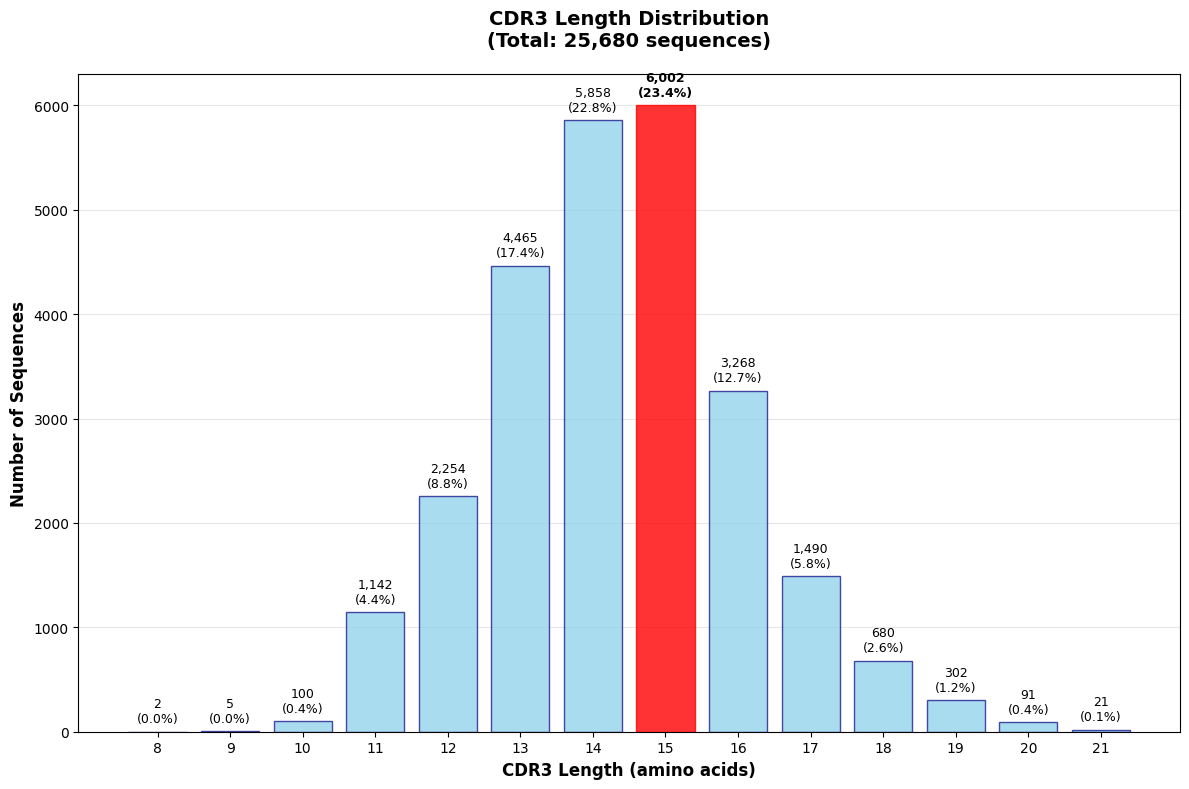

Shared antigens plot saved to: /mnt/d/TCRMI/figures/covid/shared_antigens_all_symptoms.pdf


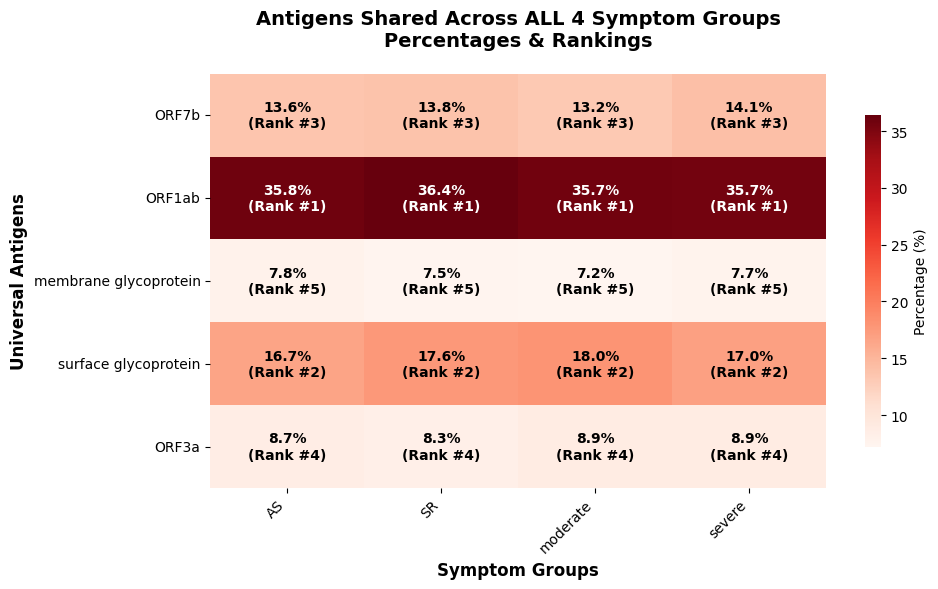

✅ Created visualization for 5 universal antigen(s)


In [26]:
# 使用方式
symptom_analysis = comprehensive_analysis_all_symptoms_only(
    result_df, 
    save_dir="/mnt/d/TCRMI/figures/covid", show_plots=True)

In [28]:
universal_antigens = list(symptom_analysis['universal_antigens'].keys())
cohorts = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort.pickle')
for antigen in universal_antigens:
    temp_dict = {}
    for cohort, df in cohorts.items():
        if cohort == "HC": continue
        merged_df = df.merge(
                            result_df[['Patient_ID', 'CDR3_sequence', 'Matched_Epitope', 'Matched_Antigen', 'Matched_Organism', 'Symptom']],
                            left_on=['patient', 'cdr3B'],
                            right_on=['Patient_ID', 'CDR3_sequence'],
                            how='left'  # Keep all rows from df2, add matching info from df1
                        )
        # Drop the duplicate columns from the merge
        merged_df = merged_df.drop(['Patient_ID', 'CDR3_sequence'], axis=1)
        merged_df = merged_df.dropna(subset=['Matched_Epitope', 'Matched_Antigen', 'Matched_Organism'])
        temp_df = merged_df[merged_df['Matched_Antigen'] == antigen]
        temp_dict[cohort] = temp_df
        print(cohort, temp_df.shape[0])
        
    with open(f'/mnt/d/TCRMI/results/covid/cohort_{antigen}.pickle', 'wb') as f:
        pickle.dump(temp_dict, f)

AS 345
moderate 889
severe 931
SR 1374
AS 914
moderate 2394
severe 2360
SR 3629
AS 200
moderate 484
severe 507
SR 744
AS 429
moderate 1208
severe 1120
SR 1770
AS 223
moderate 596
severe 595
SR 825


In [ ]:
universal_antigens = list(symptom_analysis['universal_antigens'].keys())
cohorts = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort.pickle')
for antigen in universal_antigens:
    temp_dict = {}
    for cohort, df in cohorts.items():
        if cohort == "HC": continue
        df['raw_cdr3B'] = df['cdr3B'].str.replace('-', '', regex=False)
        merged_df = df.merge(
                            result_df[['Patient_ID', 'CDR3_sequence', 'Matched_Epitope', 'Matched_Antigen', 'Matched_Organism', 'Symptom']],
                            left_on=['patient', 'raw_cdr3B'],
                            right_on=['Patient_ID', 'CDR3_sequence'],
                            how='left'  # Keep all rows from df2, add matching info from df1
                        )
        # Drop the duplicate columns from the merge
        merged_df = merged_df.drop(['Patient_ID', 'CDR3_sequence', 'raw_cdr3B'], axis=1)
        merged_df = merged_df.dropna(subset=['Matched_Epitope', 'Matched_Antigen', 'Matched_Organism'])
        temp_df = merged_df[merged_df['Matched_Antigen'] == antigen]
        temp_dict[cohort] = temp_df
        print(cohort, temp_df.shape[0])
        
    with open(f'/mnt/d/TCRMI/results/covid/amino/cohort_{antigen}.pickle', 'wb') as f:
        pickle.dump(temp_dict, f)

In [9]:
def create_amino_acid_dictionary():
    """
    Create a dictionary to map amino acids to discrete digits
    """
    # Standard 20 amino acids + some additional ones that might appear
    amino_acids = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 
                   'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V',
                   'B', 'Z', 'X', 'U', 'O']  # Additional amino acids
    
    aa_to_digit = {aa: i+1 for i, aa in enumerate(amino_acids)}  # Start from 1, 0 for padding
    digit_to_aa = {i+1: aa for i, aa in enumerate(amino_acids)}
    digit_to_aa[0] = 'PAD'  # For padding
    
    return aa_to_digit, digit_to_aa

def create_antigen_dictionary(universal_antigens):
    """
    Create a dictionary to map antigens to discrete digits
    """
    antigen_to_digit = {antigen: i for i, antigen in enumerate(universal_antigens)}
    digit_to_antigen = {i: antigen for i, antigen in enumerate(universal_antigens)}
    
    return antigen_to_digit, digit_to_antigen

def sequence_to_digits(sequence, aa_to_digit, max_length=None):
    """
    Convert amino acid sequence to array of digits
    """
    digits = [aa_to_digit.get(aa, 0) for aa in sequence]  # 0 for unknown amino acids
    
    if max_length:
        if len(digits) < max_length:
            digits.extend([0] * (max_length - len(digits)))  # Pad with 0
        elif len(digits) > max_length:
            digits = digits[:max_length]  # Truncate
    
    return np.array(digits)

def sequences_to_matrix(sequences, aa_to_digit, max_length):
    """
    Convert list of sequences to sparse matrix
    """
    n_sequences = len(sequences)
    n_features = max_length * len(aa_to_digit)  # One-hot encoding
    
    # Create sparse matrix
    all_sequences = []
    
    for seq_idx, sequence in enumerate(sequences):
        digits = sequence_to_digits(sequence, aa_to_digit, max_length)
        all_sequences.append(digits) 
    
    all_sequences = np.stack(all_sequences)
    #sparse_matrix = csr_matrix(all_sequences)
    
    return all_sequences

def analyze_with_mcci_selection(result_df, analysis_results):
    """
    Perform MCCI feature selection on CDR3 sequences for each symptom group
    """
    
    # Create dictionaries
    aa_to_digit, digit_to_aa = create_amino_acid_dictionary()
    
    print(f"\n{'='*80}")
    print("AMINO ACID TO DIGIT MAPPING")
    print(f"{'='*80}")
    print("Amino acid dictionary:")
    for aa, digit in sorted(aa_to_digit.items()):
        print(f"'{aa}': {digit}", end="  ")
        if digit % 10 == 0:
            print()  # New line every 10 items
    print("\n")
    
    # Get universal antigens
    universal_antigens = list(analysis_results['universal_antigens'].keys())
    
    if not universal_antigens:
        print("❌ No universal antigens found. Cannot proceed with MCCI analysis.")
        return None
    
    antigen_to_digit, digit_to_antigen = create_antigen_dictionary(universal_antigens)
    
    print(f"UNIVERSAL ANTIGEN TO DIGIT MAPPING")
    print(f"{'='*50}")
    print("Antigen dictionary:")
    for antigen, digit in antigen_to_digit.items():
        print(f"'{antigen}': {digit}")
    print()
    
    popular_len = analysis_results['global_most_popular_length']
    print(f"Using global most popular CDR3 length: {popular_len}")
    print(f"Universal antigens: {universal_antigens}")
    
    mcci_results = {}
    
    # Process each symptom group
    for symptom in result_df.Symptom.unique():
        print(f"\n{'='*60}")
        print(f"PROCESSING {symptom.upper()} GROUP")
        print(f"{'='*60}")
        
        symptom_df = result_df[result_df.Symptom == symptom]
        symptom_df = symptom_df.drop_duplicates(subset=['CDR3_sequence', 'Matched_Antigen'])
        
        # Filter for sequences with popular length AND universal antigens
        temp = symptom_df[
            (symptom_df['CDR3_sequence'].str.len() == popular_len) & 
            (symptom_df['Matched_Antigen'].isin(universal_antigens))
        ]
        
        print(f"Total sequences in {symptom}: {len(symptom_df):,}")
        print(f"Sequences with length {popular_len}: {len(symptom_df[symptom_df['CDR3_sequence'].str.len() == popular_len]):,}")
        print(f"Sequences with universal antigens: {len(symptom_df[symptom_df['Matched_Antigen'].isin(universal_antigens)]):,}")
        print(f"Filtered sequences (length {popular_len} + universal antigens): {len(temp):,}")
        
        if len(temp) < 10:  # Need minimum samples for MCCI
            print(f"⚠️  Too few samples ({len(temp)}) for MCCI analysis. Skipping {symptom}.")
            continue
        
        # 1. Split CDR3 sequences into arrays
        print(f"\n1. Converting CDR3 sequences to digit arrays...")
        cdr3_sequences = temp['CDR3_sequence'].tolist()
        X_matrix = sequences_to_matrix(cdr3_sequences, aa_to_digit, popular_len)
        print(f"Matrix shape: {X_matrix.shape}")

        # 3. Convert target antigens to digits
        print(f"\n3. Converting target antigens to classification labels...")
        target_antigens = temp['Matched_Antigen'].values
        y = np.array([antigen_to_digit[antigen] for antigen in target_antigens])
        
        print(f"Target antigen distribution:")
        unique_targets, counts = np.unique(y, return_counts=True)
        for target_digit, count in zip(unique_targets, counts):
            antigen_name = digit_to_antigen[target_digit]
            percentage = (count / len(y)) * 100
            print(f"  {antigen_name} (label {target_digit}): {count:,} ({percentage:.1f}%)")
        
        # selector = MCCISelector(alpha=0.2, num_samples=100, random_state=0)
        # n_features_to_select = popular_len
        # X_selected = selector.fit_transform(X_matrix, y, n_features_to_select)
        # explainer = MCCIExplainability(selector)
        # importance_df = explainer.get_feature_importance()
        from sklearn.feature_selection import mutual_info_classif
        from sklearn.preprocessing import MinMaxScaler
        
        importance_score = mutual_info_classif(X_matrix, y, random_state=0, discrete_features=True)
        # Min-Max normalization
        scaler = MinMaxScaler()
        importance_score = scaler.fit_transform(importance_score.reshape(-1, 1)).flatten()

        importance_df = pd.DataFrame({
                        'Feature': [f'Feature {i}' for i in range(len(importance_score))],
                        'Importance': importance_score
                    })
        # Sort by importance in descending order and reset index
        importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
        
        mcci_results[symptom] = {
                'original_samples': len(temp),
                'original_sequences': cdr3_sequences,
                'original_features': X_matrix.shape[1],
                'selected_features': X_matrix.shape[1],
                'selected_feature_indices': importance_df,
            }
        
    return mcci_results
        
def save_mcci_results(mcci_analysis, output_dir):
    """
    Save MCCI analysis results
    """
    if not mcci_analysis:
        return
    
    # Save dictionaries
    import json
    
    # Save amino acid dictionary
    with open(os.path.join(output_dir, "amino_acid_dictionary.json"), 'w') as f:
        json.dump(mcci_analysis['aa_to_digit'], f, indent=2)
    
    # Save antigen dictionary
    with open(os.path.join(output_dir, "antigen_dictionary.json"), 'w') as f:
        json.dump(mcci_analysis['antigen_to_digit'], f, indent=2)
    
    # Save MCCI results summary
    mcci_summary = []
    for symptom, results in mcci_analysis['mcci_results'].items():
        mcci_summary.append({
            'Symptom': symptom,
            'Original_Samples': results['original_samples'],
            'Original_Features': results['original_features'],
            'Selected_Features': results['selected_features'],
            'Feature_Reduction_Percent': ((results['original_features'] - results['selected_features']) / results['original_features'] * 100),
            'Top_10_Selected_Features': ', '.join(results['feature_interpretation'][:10])
        })
    
    mcci_summary_df = pd.DataFrame(mcci_summary)
    mcci_summary_df.to_csv(os.path.join(output_dir, "mcci_feature_selection_summary.csv"), index=False)
    
    print(f"\n✅ MCCI analysis results saved to {output_dir}")


In [10]:
mcci_results = analyze_with_mcci_selection(result_df, symptom_analysis)


AMINO ACID TO DIGIT MAPPING
Amino acid dictionary:
'A': 1  'B': 21  'C': 5  'D': 4  'E': 7  'F': 14  'G': 8  'H': 9  'I': 10  
'K': 12  'L': 11  'M': 13  'N': 3  'O': 25  'P': 15  'Q': 6  'R': 2  'S': 16  'T': 17  'U': 24  'V': 20  
'W': 18  'X': 23  'Y': 19  'Z': 22  

UNIVERSAL ANTIGEN TO DIGIT MAPPING
Antigen dictionary:
'ORF7b': 0
'ORF1ab': 1
'membrane glycoprotein': 2
'surface glycoprotein': 3
'ORF3a': 4

Using global most popular CDR3 length: 13
Universal antigens: ['ORF7b', 'ORF1ab', 'membrane glycoprotein', 'surface glycoprotein', 'ORF3a']

PROCESSING ICU_ADULT_ACUTE GROUP
Total sequences in ICU_Adult_Acute: 5,784
Sequences with length 13: 1,299
Sequences with universal antigens: 4,748
Filtered sequences (length 13 + universal antigens): 1,097

1. Converting CDR3 sequences to digit arrays...
Matrix shape: (1097, 13)

3. Converting target antigens to classification labels...
Target antigen distribution:
  ORF7b (label 0): 163 (14.9%)
  ORF1ab (label 1): 499 (45.5%)
  membrane g

In [11]:
from scipy.stats import entropy
def gini(array):
    """Calculate the Gini coefficient of a numpy array."""
    array = np.array(array)
    if np.amin(array) < 0:
        array -= np.amin(array)
    array += 1e-9  # avoid division by zero
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n+1)
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

for cohort in mcci_results.keys():
    mcci_results[cohort]['selected_feature_indices']['Normalized'] = mcci_results[cohort]['selected_feature_indices']['Importance'] / mcci_results[cohort]['selected_feature_indices']['Importance'].sum()
    importance_entropy = entropy(mcci_results[cohort]['selected_feature_indices']['Normalized'])
    gini_coeff = gini(mcci_results[cohort]['selected_feature_indices']['Normalized'])
    mcci_results[cohort]['assess_importance'] = importance_entropy
    mcci_results[cohort]['gini_coeff'] = gini_coeff

In [ ]:
def plot_feature_importance(mcci_result):
    """
    Plot feature importance for each symptom with Position labels
    """
    # Set up the plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    # Define colors for each symptom
    colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']  # Red, Blue, Orange, Green
    
    symptoms = list(mcci_result.keys())
    
    for idx, symptom in enumerate(symptoms):
        ax = axes[idx]
        
        # Get the data
        df = mcci_result[symptom]['selected_feature_indices'].copy()
        
        # Replace "Feature" with "Position" and convert to numeric
        df['Position'] = df['Feature'].str.replace('Feature ', '').astype(int)
        df['Position_Label'] = 'Position ' + df['Position'].astype(str)
        
        # Sort by importance (descending)
        df = df.sort_values('Importance', ascending=True)  # ascending=True for horizontal bar plot
        
        # Create horizontal bar plot
        bars = ax.barh(range(len(df)), df['Importance'], color=colors[idx], alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Customize the plot
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['Position_Label'], fontsize=10)
        ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
        ax.set_title(f'{symptom.upper()}\n(n={mcci_result[symptom]["original_samples"]} samples)', 
                    fontsize=14, fontweight='bold', pad=20)
        
        # Add value labels on bars
        for i, (bar, importance) in enumerate(zip(bars, df['Importance'])):
            ax.text(importance + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{importance:.2f}', va='center', ha='left', fontsize=9, fontweight='bold')
        
        # Set x-axis limits
        ax.set_xlim(0, max(df['Importance']) * 1.15)
        
        # Add grid
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # Highlight top 3 positions
        top_3_indices = df.nlargest(3, 'Importance').index
        for i, bar in enumerate(bars):
            if df.iloc[i].name in top_3_indices:
                bar.set_alpha(1.0)
                bar.set_edgecolor('black')
                bar.set_linewidth(2)
    
    plt.tight_layout()
    plt.suptitle('TCR Position Importance by COVID-19 Symptom Severity', 
                fontsize=16, fontweight='bold', y=1.02)
    
plot_feature_importance(mcci_results)

In [13]:
def create_radar_chart_with_top_n(mcci_result, 
                                  top_n=3,
                                  highlight_marker='*',
                                  highlight_color='gold',
                                  highlight_edge_color='black',
                                  highlight_size=15,
                                  show_rank_labels=True,
                                  rank_label_color='darkred',
                                  rank_label_bg='white',
                                  regular_marker='o',
                                  regular_size=6,
                                  line_width=2,
                                  fill_alpha=0.25,
                                  grid_alpha=0.3,
                                  figsize=(12, 12),
                                  ylim_max=1.0,
                                  print_summary=True,
                                  savepath=None):
    """
    Create radar charts showing position importance patterns with top N positions highlighted
    
    Parameters:
    -----------
    mcci_result : dict
        Results from MCCI analysis
    top_n : int, default=3
        Number of top positions to highlight
    highlight_marker : str, default='*'
        Marker style for top positions ('*', 'o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '+', 'x')
    highlight_color : str, default='gold'
        Color for highlighted markers
    highlight_edge_color : str, default='black'
        Edge color for highlighted markers
    highlight_size : int, default=15
        Size of highlighted markers
    show_rank_labels : bool, default=True
        Whether to show rank numbers (#1, #2, etc.)
    rank_label_color : str, default='darkred'
        Color for rank labels
    rank_label_bg : str, default='white'
        Background color for rank labels
    regular_marker : str, default='o'
        Marker style for regular positions
    regular_size : int, default=6
        Size of regular markers
    line_width : int, default=2
        Width of the connecting lines
    fill_alpha : float, default=0.25
        Transparency of filled areas
    grid_alpha : float, default=0.3
        Transparency of grid lines
    figsize : tuple, default=(12, 12)
        Figure size
    ylim_max : float, default=0.8
        Maximum value for radial axis
    print_summary : bool, default=True
        Whether to print summary of top positions
    savepath : str, optional
        Path to save the figure
    """
    
    from math import pi
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Check if we have any results
    if not mcci_result:
        print("❌ No MCCI results to plot.")
        return
    
    symptoms = list(mcci_result.keys())
    n_symptoms = len(symptoms)
    
    # Create subplot layout based on number of symptoms
    if n_symptoms == 1:
        fig, axes = plt.subplots(1, 1, figsize=figsize, subplot_kw=dict(projection='polar'))
        axes = [axes]
    elif n_symptoms == 2:
        fig, axes = plt.subplots(1, 2, figsize=figsize, subplot_kw=dict(projection='polar'))
    elif n_symptoms <= 4:
        fig, axes = plt.subplots(2, 2, figsize=figsize, subplot_kw=dict(projection='polar'))
        axes = axes.flatten()
    else:
        # For more than 4 symptoms, create a larger grid
        rows = int(np.ceil(n_symptoms / 3))
        fig, axes = plt.subplots(rows, 3, figsize=(figsize[0]*1.2, figsize[1]*rows/2), 
                                subplot_kw=dict(projection='polar'))
        axes = axes.flatten()
    
    colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6', '#1abc9c', '#f1c40f', '#e67e22']
    
    # Determine CDR3 length from the first symptom's data
    first_symptom = symptoms[0]
    first_df = mcci_result[first_symptom]['selected_feature_indices']
    
    # Extract position numbers to determine CDR3 length
    if 'Feature' in first_df.columns:
        # Extract numeric positions from feature names
        positions_in_data = []
        for feature in first_df['Feature']:
            try:
                if 'Feature ' in str(feature):
                    pos = int(str(feature).replace('Feature ', ''))
                    positions_in_data.append(pos)
                else:
                    pos = int(feature)
                    positions_in_data.append(pos)
            except:
                continue
        
        if positions_in_data:
            cdr3_length = max(positions_in_data) + 1  # +1 because positions are 0-indexed
        else:
            cdr3_length = 14  # Default fallback
    else:
        cdr3_length = 14  # Default fallback
    
    print(f"📊 Creating radar chart for CDR3 length: {cdr3_length}")
    print(f"📊 Number of symptoms to plot: {n_symptoms}")
    
    # Prepare angles for radar chart
    positions = list(range(cdr3_length))
    angles = [n / cdr3_length * 2 * pi for n in positions]
    angles += angles[:1]  # Complete the circle
    
    if print_summary:
        print(f"\n{'='*60}")
        print(f"TOP {top_n} IMPORTANT POSITIONS SUMMARY")
        print(f"{'='*60}")
    
    for idx, symptom in enumerate(symptoms):
        ax = axes[idx]
        
        # Get importance scores for all positions
        df = mcci_result[symptom]['selected_feature_indices'].copy()
        
        # Extract position numbers and importance scores
        position_importance = {}
        for _, row in df.iterrows():
            try:
                if 'Feature' in df.columns:
                    if 'Feature ' in str(row['Feature']):
                        pos = int(str(row['Feature']).replace('Feature ', ''))
                    else:
                        pos = int(row['Feature'])
                else:
                    pos = int(row.iloc[0])  # First column as position
                
                importance = float(row['Importance'])
                position_importance[pos] = importance
            except:
                continue
        
        # Create full importance array
        importance_scores = [0.0] * cdr3_length
        for pos, importance in position_importance.items():
            if 0 <= pos < cdr3_length:
                importance_scores[pos] = importance
        
        # Find top N positions
        top_n_indices = np.argsort(importance_scores)[-top_n:]  # Get indices of top N values
        top_n_positions = set(top_n_indices)
        
        # Print summary for this symptom
        if print_summary:
            print(f"\n{symptom.upper()}:")
            sorted_positions = sorted(top_n_positions, 
                                    key=lambda x: importance_scores[x], reverse=True)
            for rank, pos in enumerate(sorted_positions):
                if importance_scores[pos] > 0:
                    print(f"  #{rank+1}: Position {pos} (Importance: {importance_scores[pos]:.4f})")
        
        importance_scores_plot = importance_scores + importance_scores[:1]  # Complete the circle
        
        # Plot the main line and fill
        ax.plot(angles, importance_scores_plot, regular_marker + '-', linewidth=line_width, 
                label=symptom.upper(), color=colors[idx % len(colors)], markersize=regular_size)
        ax.fill(angles, importance_scores_plot, alpha=fill_alpha, color=colors[idx % len(colors)])
        
        # Highlight top N positions with special markers
        for pos in top_n_positions:
            if importance_scores[pos] > 0:  # Only mark if there's actual importance
                ax.plot(angles[pos], importance_scores[pos], 
                       marker=highlight_marker, markersize=highlight_size, 
                       color=highlight_color, 
                       markeredgecolor=highlight_edge_color, markeredgewidth=1.5, 
                       zorder=10)
        
        # Add text annotations for top N positions
        if show_rank_labels:
            for rank, pos in enumerate(sorted(top_n_positions, 
                                            key=lambda x: importance_scores[x], reverse=True)):
                if importance_scores[pos] > 0:
                    # Calculate text position (slightly outside the point)
                    text_radius = min(importance_scores[pos] + 0.05, ylim_max - 0.05)
                    ax.annotate(f'#{rank+1}', 
                               xy=(angles[pos], importance_scores[pos]),
                               xytext=(angles[pos], text_radius),
                               fontsize=10, fontweight='bold',
                               ha='center', va='center',
                               color=rank_label_color,
                               bbox=dict(boxstyle='round,pad=0.2', 
                                       facecolor=rank_label_bg, alpha=0.8))
        
        # Customize
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([f'Pos {i}' for i in positions], fontsize=10)
        ax.set_ylim(0, ylim_max)
        
        # Get sample count
        sample_count = mcci_result[symptom].get('original_samples', 0)
        ax.set_title(f'{symptom.upper()}\n(n={sample_count} samples)', 
                    size=14, fontweight='bold', pad=20)
        ax.grid(True, alpha=grid_alpha)
        
        # Add radial labels
        y_ticks = np.arange(0.2, ylim_max + 0.1, 0.2)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f'{tick:.1f}' for tick in y_ticks], fontsize=8)
    
    # Hide unused subplots if any
    for idx in range(n_symptoms, len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend for the highlight markers
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker=highlight_marker, color='w', 
                             markerfacecolor=highlight_color,
                             markeredgecolor=highlight_edge_color, 
                             markersize=highlight_size, 
                             label=f'Top {top_n} Positions')]
    fig.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, 0.02), ncol=1)
    
    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight', transparent=True)
        print(f"\n✅ Radar chart saved to: {savepath}")
    
    return fig

📊 Creating radar chart for CDR3 length: 13
📊 Number of symptoms to plot: 6

TOP 3 IMPORTANT POSITIONS SUMMARY

ICU_ADULT_ACUTE:
  #1: Position 8 (Importance: 1.0000)
  #2: Position 5 (Importance: 0.8422)
  #3: Position 6 (Importance: 0.8279)

ICU_ADULT_CONVALESCENT:
  #1: Position 7 (Importance: 1.0000)
  #2: Position 4 (Importance: 0.9091)
  #3: Position 6 (Importance: 0.9073)

NON_ICU_KID_ACUTE:
  #1: Position 4 (Importance: 1.0000)
  #2: Position 9 (Importance: 0.9619)
  #3: Position 3 (Importance: 0.8643)

NON_ICU_KID_CONVALESCENT:
  #1: Position 9 (Importance: 1.0000)
  #2: Position 4 (Importance: 0.9390)
  #3: Position 3 (Importance: 0.7948)

NON_ICU_ADULT_ACUTE:
  #1: Position 9 (Importance: 1.0000)
  #2: Position 2 (Importance: 0.7887)
  #3: Position 6 (Importance: 0.7847)

NON_ICU_ADULT_CONVALESCENT:
  #1: Position 4 (Importance: 1.0000)
  #2: Position 2 (Importance: 0.9881)
  #3: Position 9 (Importance: 0.9615)

✅ Radar chart saved to: /mnt/d/TCRMI/figures/covid_children/posi

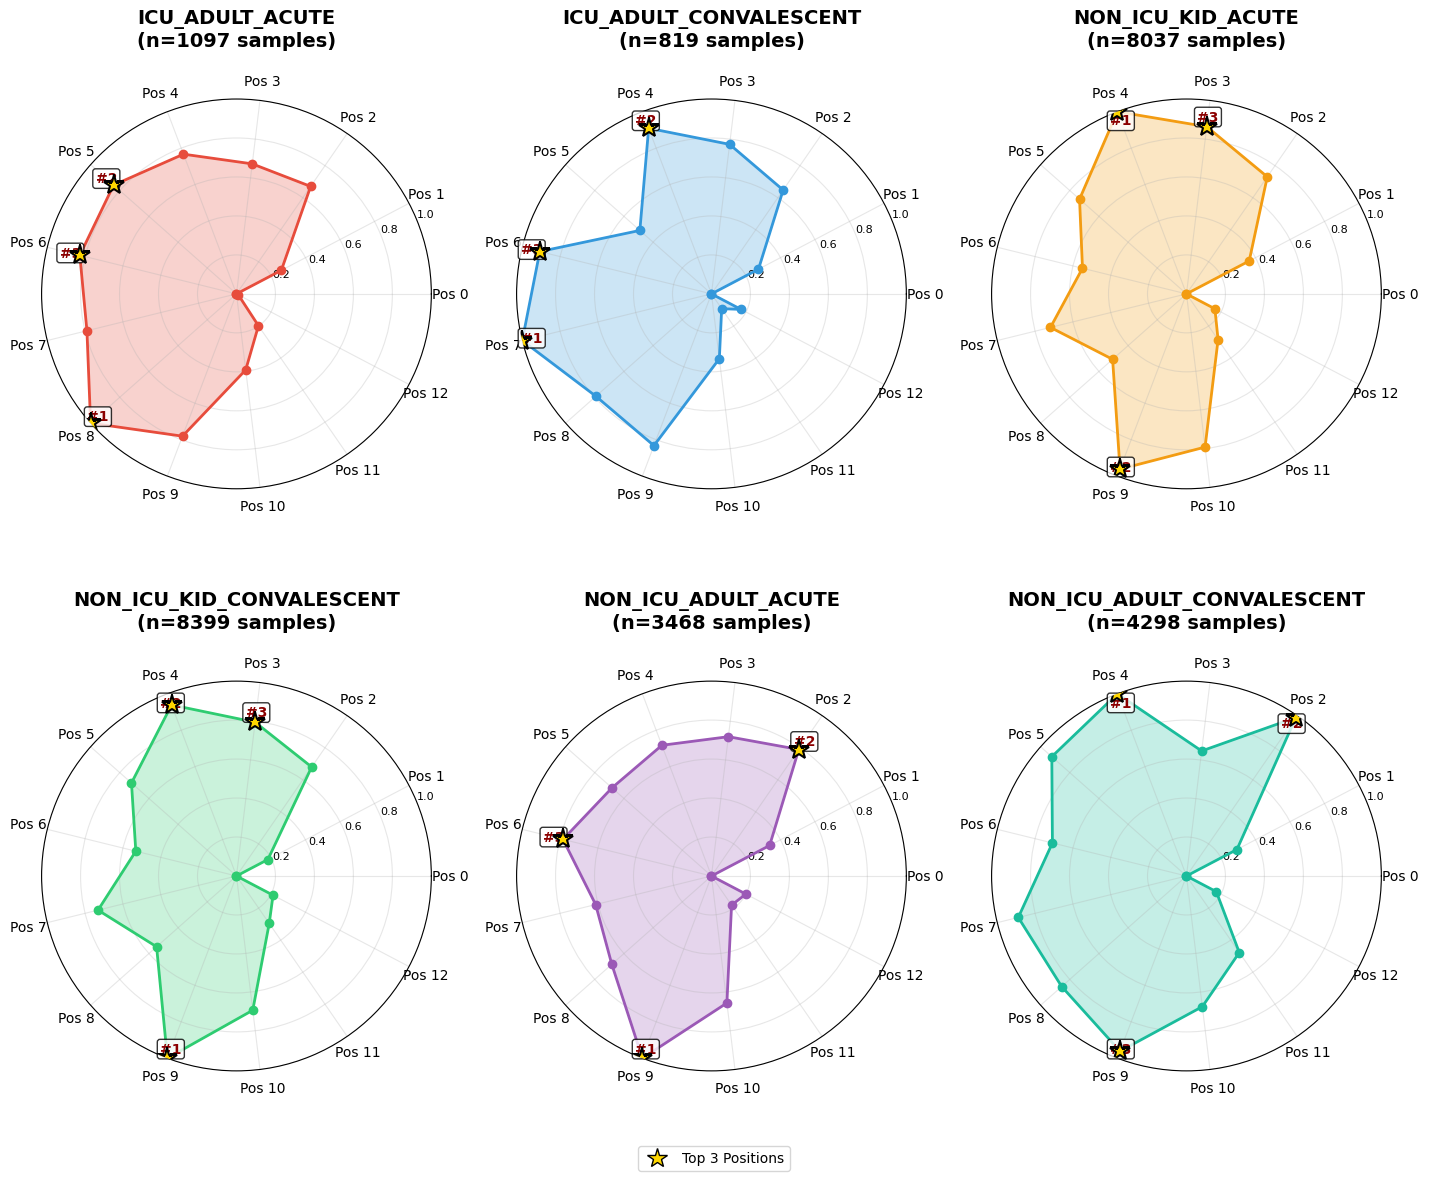

In [14]:
fig = create_radar_chart_with_top_n(mcci_results, 
                             top_n=3,
                             savepath="/mnt/d/TCRMI/figures/covid/cohort/positions_selector.pdf") #"/mnt/d/TCRMI/figures/covid_children/positions_selector.pdf"

Summary of Changes from Acute to Convalescent:

Non_ICU_Adult:
  Entropy: 2.3968 → 2.4031 (Δ: +0.0063)
  Gini Coefficient: 0.2667 → 0.2643 (Δ: -0.0024)

ICU_Adult:
  Entropy: 2.3234 → 2.3351 (Δ: +0.0117)
  Gini Coefficient: 0.3229 → 0.3388 (Δ: +0.0159)

Non_ICU_Kid:
  Entropy: 2.3944 → 2.3858 (Δ: -0.0086)
  Gini Coefficient: 0.2852 → 0.2928 (Δ: +0.0075)


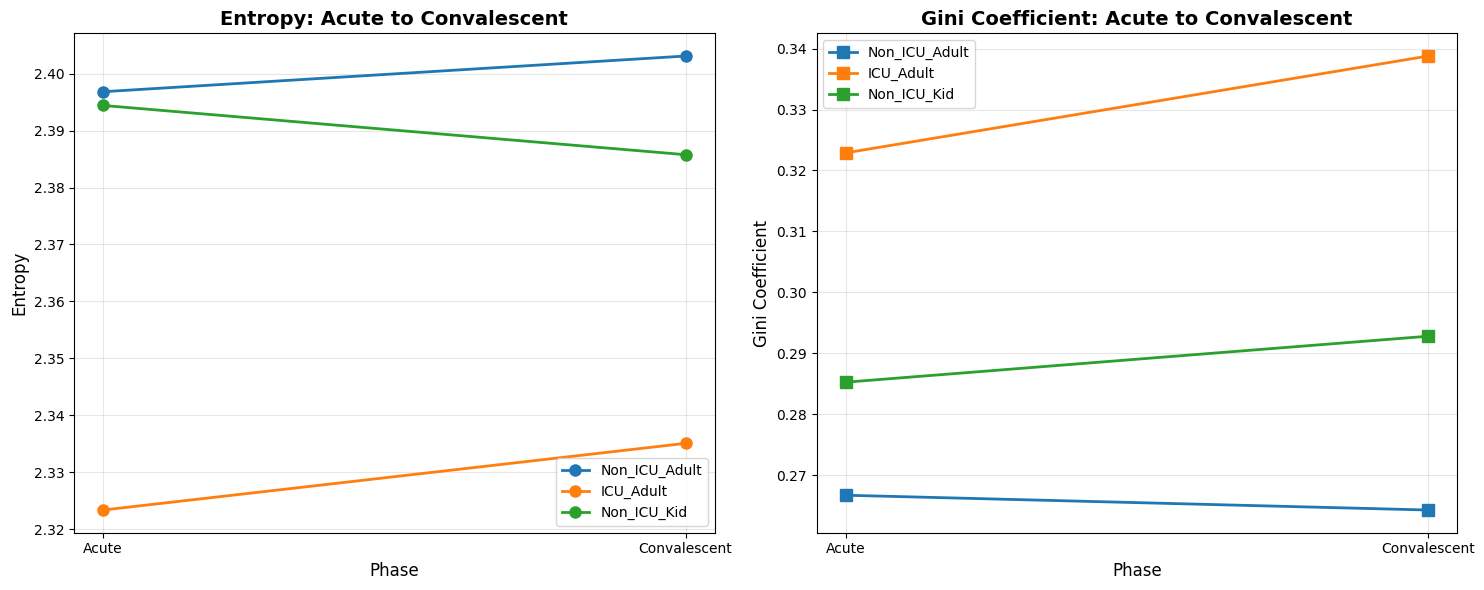

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract data from mcci_results
cohorts = ['Non_ICU_Adult', 'ICU_Adult', 'Non_ICU_Kid']
phases = ['Acute', 'Convalescent']

# Prepare data for plotting
plot_data = []

for cohort in cohorts:
    for phase in phases:
        key = f"{cohort}_{phase}"
        if key in mcci_results:
            plot_data.append({
                'Cohort': cohort,
                'Phase': phase,
                'assess_importance': mcci_results[key]['assess_importance'],
                'gini_coeff': mcci_results[key]['gini_coeff']
            })

# Convert to DataFrame
df = pd.DataFrame(plot_data)

# Create the line plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: assess_importance
for cohort in cohorts:
    cohort_data = df[df['Cohort'] == cohort]
    if len(cohort_data) == 2:  # Make sure we have both acute and convalescent data
        ax1.plot(['Acute', 'Convalescent'], 
                cohort_data['assess_importance'].values, 
                marker='o', linewidth=2, markersize=8, label=cohort)

ax1.set_title('Entropy: Acute to Convalescent', fontsize=14, fontweight='bold')
ax1.set_xlabel('Phase', fontsize=12)
ax1.set_ylabel('Entropy', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: gini_coeff
for cohort in cohorts:
    cohort_data = df[df['Cohort'] == cohort]
    if len(cohort_data) == 2:  # Make sure we have both acute and convalescent data
        ax2.plot(['Acute', 'Convalescent'], 
                cohort_data['gini_coeff'].values, 
                marker='s', linewidth=2, markersize=8, label=cohort)

ax2.set_title('Gini Coefficient: Acute to Convalescent', fontsize=14, fontweight='bold')
ax2.set_xlabel('Phase', fontsize=12)
ax2.set_ylabel('Gini Coefficient', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Print summary of changes
print("Summary of Changes from Acute to Convalescent:")
print("=" * 50)

for cohort in cohorts:
    cohort_data = df[df['Cohort'] == cohort].sort_values('Phase')
    if len(cohort_data) == 2:
        acute_assess = cohort_data.iloc[0]['assess_importance']
        conv_assess = cohort_data.iloc[1]['assess_importance']
        acute_gini = cohort_data.iloc[0]['gini_coeff']
        conv_gini = cohort_data.iloc[1]['gini_coeff']
        
        assess_change = conv_assess - acute_assess
        gini_change = conv_gini - acute_gini
        
        print(f"\n{cohort}:")
        print(f"  Entropy: {acute_assess:.4f} → {conv_assess:.4f} (Δ: {assess_change:+.4f})")
        print(f"  Gini Coefficient: {acute_gini:.4f} → {conv_gini:.4f} (Δ: {gini_change:+.4f})")
plt.savefig("/mnt/d/TCRMI/figures/covid_children/Entropy_and_Gini.pdf", bbox_inches='tight', transparent=True)

In [37]:
mcci_results.keys()

dict_keys(['ICU_Adult_Acute', 'ICU_Adult_Convalescent', 'Non_ICU_Kid_Acute', 'Non_ICU_Kid_Convalescent', 'Non_ICU_Adult_Acute', 'Non_ICU_Adult_Convalescent'])

LogerMaker plot functions:
1. create_sequence_logo(sequences, title="CDR3 Sequence Logo", figsize=(12, 4))
2. create_information_content_logo(sequences, title="CDR3 Sequence Logo", figsize=(12, 4))

In [28]:
import logomaker
from collections import Counter

def create_sequence_logo(sequences, title="CDR3 Sequence Logo", figsize=(12, 4), savepath=None):
    """
    Create a sequence logo from a list of CDR3 sequences
    
    Parameters:
    sequences: list of CDR3 sequences
    title: title for the plot
    figsize: figure size tuple
    """
    
    # Filter out any None or empty sequences
    sequences = [seq for seq in sequences if seq and isinstance(seq, str)]
    
    if not sequences:
        print("No valid sequences found!")
        return
    
    # Find the maximum length to pad sequences
    max_length = max(len(seq) for seq in sequences)
    print(f"Processing {len(sequences)} sequences with max length {max_length}")
    
    # Create position-wise amino acid frequency matrix
    position_counts = []
    
    for pos in range(max_length):
        aa_counts = Counter()
        valid_sequences_at_pos = 0
        
        for seq in sequences:
            if pos < len(seq):
                aa = seq[pos]
                if aa.isalpha():  # Only count valid amino acids
                    aa_counts[aa] += 1
                    valid_sequences_at_pos += 1
        
        # Convert counts to frequencies
        if valid_sequences_at_pos > 0:
            aa_freqs = {aa: count/valid_sequences_at_pos for aa, count in aa_counts.items()}
        else:
            aa_freqs = {}
        
        position_counts.append(aa_freqs)
    
    # Get all unique amino acids present in the sequences
    all_amino_acids = set()
    for pos_counts in position_counts:
        all_amino_acids.update(pos_counts.keys())
    
    all_amino_acids = sorted(list(all_amino_acids))
    print(f"Found amino acids: {all_amino_acids}")
    
    # Create frequency matrix
    freq_matrix = []
    for pos_counts in position_counts:
        row = [pos_counts.get(aa, 0) for aa in all_amino_acids]
        freq_matrix.append(row)
    
    # Convert to DataFrame
    freq_df = pd.DataFrame(freq_matrix, columns=all_amino_acids)
    freq_df.index = range(1, len(freq_df) + 1)  # 1-based indexing for positions
    
    # Create the logo
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create logo using information content
    logo = logomaker.Logo(freq_df, 
                         ax=ax,
                         color_scheme='chemistry',  # Color by amino acid chemistry
                         font_name='Arial Rounded MT Bold')
    
    # Customize the plot
    ax.set_xlabel('Position', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Set y-axis limits
    ax.set_ylim(0, 1.0)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust layout
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, transparent=True)
    
    return freq_df
        
def create_information_content_logo(sequences, title="CDR3 Sequence Logo", figsize=(12, 4), savepath=None):
    """
    Create a sequence logo using information content (like the uploaded figure)
    """
    
    # Filter sequences
    sequences = [seq for seq in sequences if seq and isinstance(seq, str)]
    
    if not sequences:
        print("No valid sequences found!")
        return
    
    max_length = max(len(seq) for seq in sequences)
    
    # Calculate information content for each position
    information_matrix = []
    
    for pos in range(max_length):
        aa_counts = Counter()
        total_seqs_at_pos = 0
        
        for seq in sequences:
            if pos < len(seq) and seq[pos].isalpha():
                aa_counts[seq[pos]] += 1
                total_seqs_at_pos += 1
        
        if total_seqs_at_pos == 0:
            information_matrix.append({})
            continue
        
        # Calculate frequencies
        aa_freqs = {aa: count/total_seqs_at_pos for aa, count in aa_counts.items()}
        
        # Calculate information content
        # I(i) = sum(f(i,a) * log2(f(i,a) / p(a)))
        # For simplicity, assume uniform background probability
        background_prob = 1/20  # 20 amino acids
        
        ic_values = {}
        for aa, freq in aa_freqs.items():
            if freq > 0:
                ic = freq * np.log2(freq / background_prob)
                ic_values[aa] = ic
        
        information_matrix.append(ic_values)
    
    # Get all amino acids
    all_amino_acids = set()
    for pos_ic in information_matrix:
        all_amino_acids.update(pos_ic.keys())
    all_amino_acids = sorted(list(all_amino_acids))
    
    # Create information content matrix
    ic_matrix = []
    for pos_ic in information_matrix:
        row = [pos_ic.get(aa, 0) for aa in all_amino_acids]
        ic_matrix.append(row)
    
    # Convert to DataFrame
    ic_df = pd.DataFrame(ic_matrix, columns=all_amino_acids)
    ic_df.index = range(1, len(ic_df) + 1)
    
    # Create the logo
    fig, ax = plt.subplots(figsize=figsize)
    
    logo = logomaker.Logo(ic_df,
                         ax=ax,
                         color_scheme='chemistry',
                         font_name='Arial Rounded MT Bold')
    
    # Customize
    ax.set_xlabel('Position', fontsize=12, fontweight='bold')
    ax.set_ylabel('Information Content (bits)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, transparent=True)

    return ic_df


In [29]:
mcci_results.keys()

dict_keys(['severe', 'SR', 'moderate', 'AS'])

findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.


findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

Processing 1252 sequences with max length 15
Found amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

Processing 1953 sequences with max length 15
Found amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

Processing 1347 sequences with max length 15
Found amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

Processing 473 sequences with max length 15
Found amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

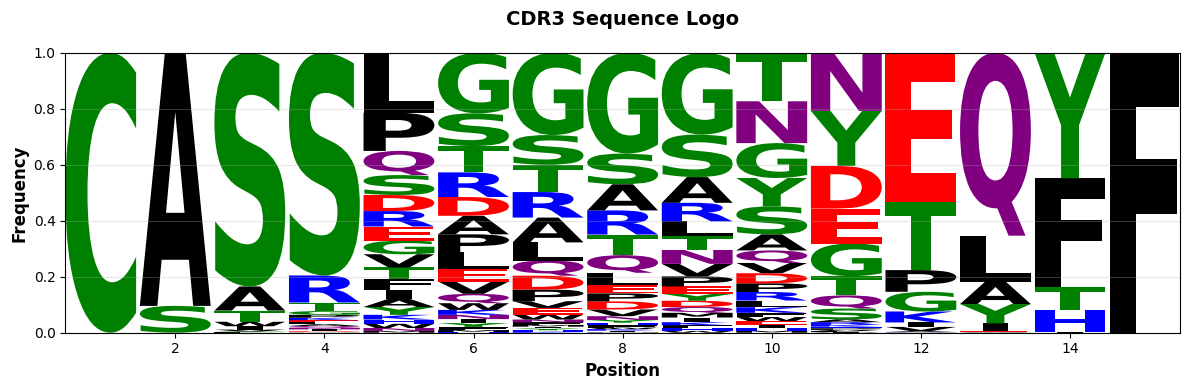

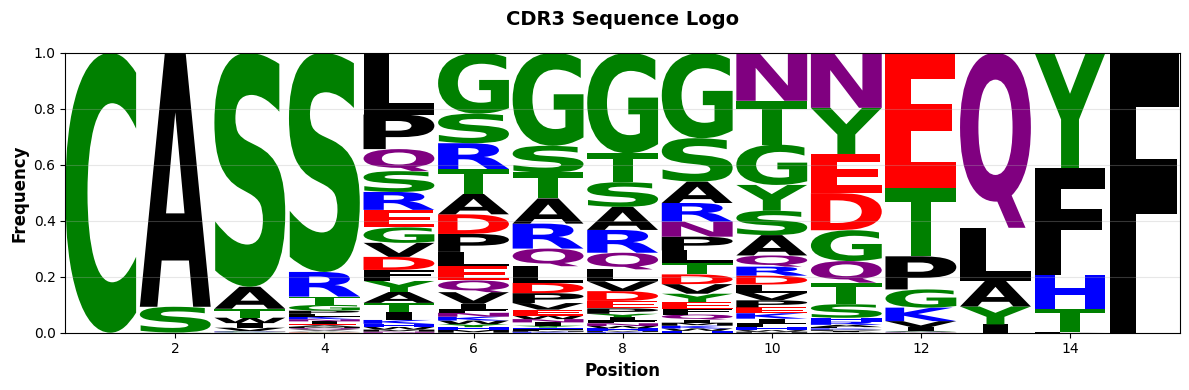

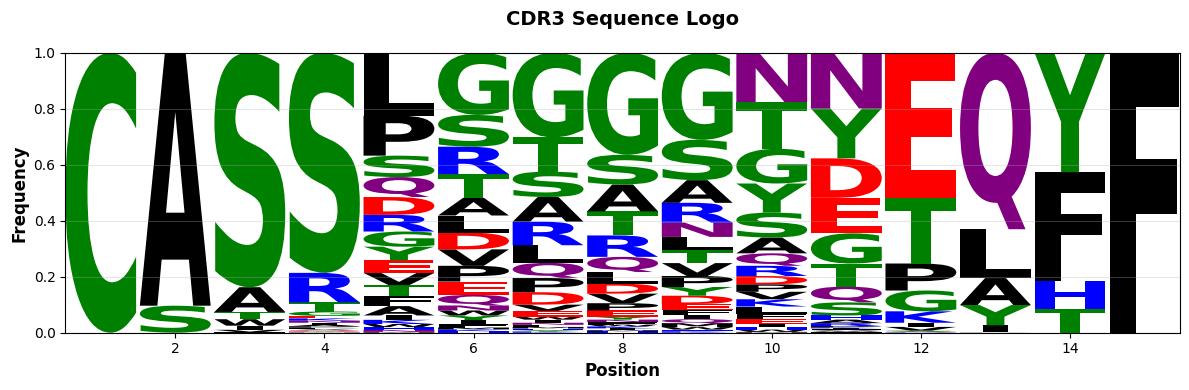

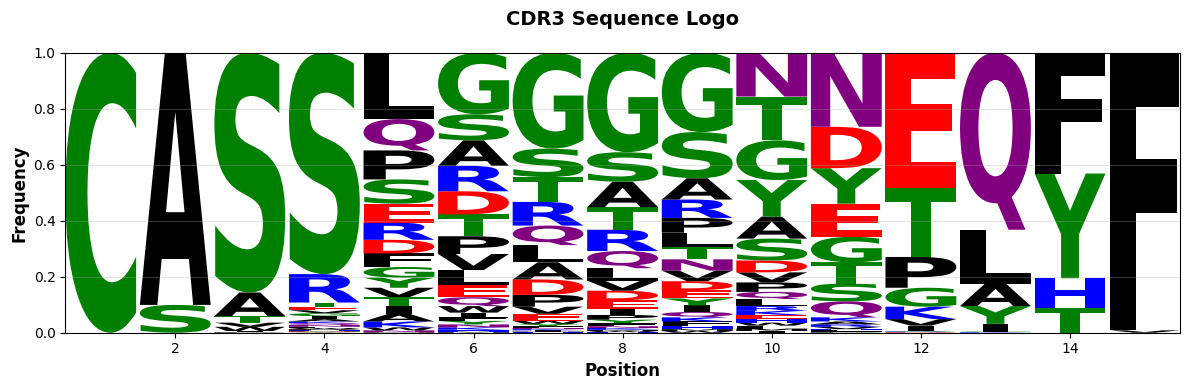

In [30]:
for id in mcci_results.keys():
    create_sequence_logo(mcci_results[id]['original_sequences'], savepath=f"/mnt/d/TCRMI/figures/covid/cohort/{id}_logomaker.pdf")

In [ ]:
create_information_content_logo(mcci_results['AS']['original_sequences'], savepath="/mnt/d/TCRMI/figures/covid_children/AS_logomaker.pdf")

In [ ]:
membrane = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_membrane/mi.pickle')
ORF1ab = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_ORF1ab/mi.pickle')
ORF3a = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_ORF3a/mi.pickle')
ORF7b = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_ORF7b/mi.pickle')
surface = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_surface/mi.pickle')

membrane_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_membrane.pickle')
ORF1ab_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_ORF1ab.pickle')
ORF3a_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_ORF3a.pickle')
ORF7b_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_ORF7b.pickle')
surface_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/cohort_surface.pickle')

In [ ]:
import seaborn as sns

def create_mi_boxplot(mi_path, samples_path, save_dir="figures/CTL/samples", 
                     selected_features=None):
    """
    Create MI distribution boxplots for either individual samples or cohort groups.
    
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    sample_ids = list(data_dict.keys())
    
    # Process each feature pair
    feature_pairs = list(mi.keys())
    if selected_features is not None:
        feature_pairs = [fp for fp in feature_pairs if fp in selected_features]
    
    # 收集所有樣本的MI數據
    all_sample_data = {}
    
    for feature1, feature2 in feature_pairs:
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        print(f"Processing {feature1} vs {feature2}: ", end="")
        
        # Prepare plot data
        plot_data = []
        for sample_idx, sample_id in enumerate(sample_ids):
                
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    #if sample_idx < len(mi_values_array):
                    plot_data.append({
                        'Sample_ID': sample_id,
                        'MI_Value': mi_values_array[sample_id],
                        'Resample_Index': resample_idx
                    })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print("No data found")
            continue
            
        # 計算每個樣本的中位數MI值
        median_mi = df_plot.groupby('Sample_ID')['MI_Value'].median()
        
        # 存儲到總體數據字典中
        for sample_id in sample_ids:
            if sample_id not in all_sample_data:
                all_sample_data[sample_id] = {}
            if sample_id in median_mi:
                all_sample_data[sample_id][(feature1, feature2)] = median_mi[sample_id]
        
        print("Done")
    
    # 創建熱圖
    create_multi_sample_heatmap(all_sample_data, save_dir)
    
    return all_sample_data

def create_multi_sample_heatmap(all_sample_data, save_dir, samples_per_row=6):
    """
    創建包含多個樣本的熱圖網格，類似於上傳的圖片
    """
    features = ['Va', 'Ja', 'CDR3a', 'Vb', 'Jb', 'CDR3b']
    feature_mapping = {
        'TRAV': 'Va',
        'TRAJ': 'Ja', 
        'cdr3A': 'CDR3a',
        'TRBV': 'Vb',
        'TRBJ': 'Jb',
        'cdr3B': 'CDR3b'
    }
    
    sample_ids = list(all_sample_data.keys())
    n_samples = len(sample_ids)
    n_rows = (n_samples + samples_per_row - 1) // samples_per_row
    
    fig, axes = plt.subplots(n_rows, samples_per_row, 
                            figsize=(samples_per_row * 3, n_rows * 2.5))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, sample_id in enumerate(sample_ids):
        row = idx // samples_per_row
        col = idx % samples_per_row
        
        # 創建矩陣
        matrix = np.zeros((6, 6))
        mi_dict = all_sample_data[sample_id]
        
        for (feature1, feature2), mi_value in mi_dict.items():
            f1_mapped = feature_mapping.get(feature1, feature1)
            f2_mapped = feature_mapping.get(feature2, feature2)
            
            if f1_mapped in features and f2_mapped in features:
                i = features.index(f1_mapped)
                j = features.index(f2_mapped)
                matrix[i, j] = mi_value
                matrix[j, i] = mi_value
 
        # 繪製熱圖
        sns.heatmap(matrix,
                   ax=axes[row, col],
                   xticklabels=features,
                   yticklabels=features,
                   annot=False,
                   cmap='RdYlBu_r',
                   cbar=False,
                   square=True)
        
        axes[row, col].set_title(sample_id, fontsize=10)
        axes[row, col].set_xlabel('')
        axes[row, col].set_ylabel('')
    
    # 隱藏多餘的子圖
    for idx in range(n_samples, n_rows * samples_per_row):
        row = idx // samples_per_row
        col = idx % samples_per_row
        axes[row, col].set_visible(False)
    
    # 添加總的顏色條
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='RdYlBu_r')
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Mutual Information (nats)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/multi_sample_mi_heatmap.png", dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved multi-sample heatmap with {n_samples} samples")


Processing TRAV vs TRBV: Done
Processing TRAV vs cdr3B: Done
Processing TRAJ vs TRBJ: Done
Processing TRAJ vs cdr3B: Done
Processing cdr3A vs TRBV: Done
Processing cdr3A vs cdr3B: Done
Processing cdr3A vs TRBJ: Done
Processing TRAV vs TRAJ: Done
Processing TRBV vs TRBJ: Done
Processing TRAV vs cdr3A: Done
Processing TRAJ vs cdr3A: Done
Processing TRBV vs cdr3B: Done
Processing TRBJ vs cdr3B: Done


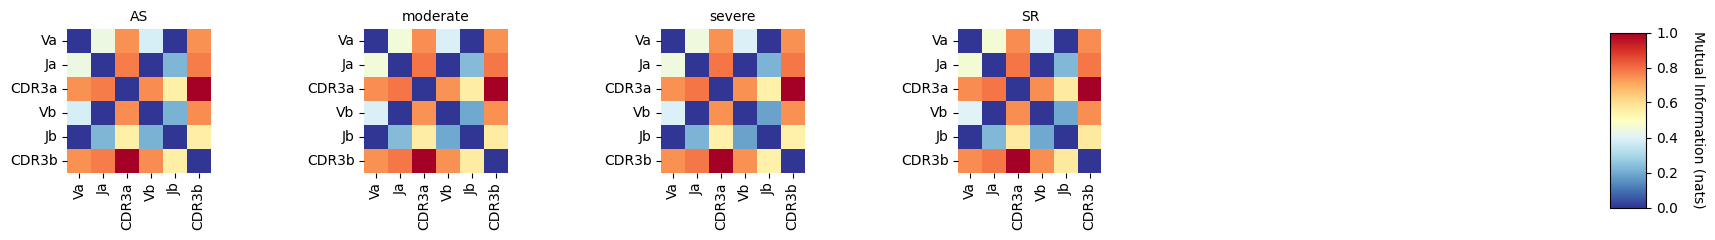

In [50]:
all_sample_data = create_mi_boxplot('/mnt/d/TCRMI/results/covid/cohort_membrane/mi.pickle', 
                  '/mnt/d/TCRMI/results/covid/cohort_membrane.pickle', 
                  save_dir=None, 
                    selected_features=None)

In [63]:
#membrane = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_membrane/mi.pickle')
#ORF1ab = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_ORF1ab/mi.pickle')
ORF3a = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_ORF3a/pos_mi.pickle')
ORF7b = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_ORF7b/pos_mi.pickle')
surface = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_surface/pos_mi.pickle')

#membrane_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_membrane.pickle')
#ORF1ab_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_ORF1ab.pickle')
ORF3a_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_ORF3a.pickle')
ORF7b_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_ORF7b.pickle')
surface_samples = pd.read_pickle('/mnt/d/TCRMI/results/covid/amino/cohort_surface.pickle')

In [104]:
import seaborn as sns

def create_sample_grid_position_mi_heatmap(mi_path, samples_path, save_dir=None, 
                                         selected_features=None, statistic='median',
                                         samples_per_row=6, figsize_per_heatmap=(2, 1.5)):
    """
    Create a grid where:
    - Each row represents a feature pair
    - Each column represents a sample
    - Each cell is a heatmap showing position-wise MI for that feature pair and sample
    
    Parameters:
    -----------
    mi_path : str
        Path to MI results pickle file
    samples_path : str  
        Path to samples data pickle file
    save_dir : str
        Directory to save figures
    selected_features : list
        List of feature pairs to plot
    statistic : str
        Statistic to use ('mean', 'median', 'max')
    samples_per_row : int
        Number of samples (heatmaps) per row
    figsize_per_heatmap : tuple
        Size of each individual heatmap (width, height)
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    sample_ids = list(data_dict.keys())
    
    # Process each feature pair
    feature_pairs = list(mi.keys())
    if selected_features is not None:
        feature_pairs = [fp for fp in feature_pairs if fp in selected_features]
    
    # Filter for categorical-sequence pairs (those with position_results)
    cat_seq_pairs = []
    for feature_pair in feature_pairs:
        if 'position_results' in mi[feature_pair]:
            cat_seq_pairs.append(feature_pair)
    
    if not cat_seq_pairs:
        print("No categorical-sequence feature pairs found with position results")
        return
    
    print(f"Found {len(cat_seq_pairs)} categorical-sequence feature pairs")
    print(f"Found {len(sample_ids)} samples")
    
    # Calculate layout
    n_feature_pairs = len(cat_seq_pairs)
    n_samples = len(sample_ids)
    n_cols = min(samples_per_row, n_samples)
    
    # Calculate figure size
    fig_width = n_cols * figsize_per_heatmap[0]
    fig_height = n_feature_pairs * figsize_per_heatmap[1]
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_feature_pairs, n_cols, 
                            figsize=(fig_width, fig_height))
    
    # Handle edge cases for axes indexing
    if n_feature_pairs == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_feature_pairs == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]
    
    # Store all data for consistent color scaling
    all_matrices = []
    pair_sample_data = {}
    
    print("Processing data for consistent color scaling...")
    
    # First pass: collect all data
    for pair_idx, (feature1, feature2) in enumerate(cat_seq_pairs):
        print(f"  Processing {feature1} vs {feature2}")
        
        position_results = mi[(feature1, feature2)]['position_results']
        positions = sorted([int(pos.split('_')[1]) for pos in position_results.keys()])
        n_bootstrap = len(list(position_results.values())[0])
        
        pair_sample_data[(feature1, feature2)] = {}
        
        for sample_id in sample_ids:
            # Create position-wise MI array for this sample
            sample_mi_by_position = []
            
            for pos in positions:
                pos_key = f'pos_{pos}'
                if pos_key in position_results:
                    bootstrap_values = []
                    
                    for bootstrap_idx in range(n_bootstrap):
                        bootstrap_data = position_results[pos_key][bootstrap_idx]
                        if sample_id in bootstrap_data:
                            bootstrap_values.append(bootstrap_data[sample_id])
                    
                    if bootstrap_values:
                        if statistic == 'mean':
                            sample_mi_by_position.append(np.mean(bootstrap_values))
                        elif statistic == 'median':
                            sample_mi_by_position.append(np.median(bootstrap_values))
                        elif statistic == 'max':
                            sample_mi_by_position.append(np.max(bootstrap_values))
                        else:
                            sample_mi_by_position.append(np.mean(bootstrap_values))
                    else:
                        sample_mi_by_position.append(0.0)
                else:
                    sample_mi_by_position.append(0.0)
            
            # Convert to matrix (1 x n_positions for individual sample heatmap)
            sample_matrix = np.array(sample_mi_by_position).reshape(1, -1)
            pair_sample_data[(feature1, feature2)][sample_id] = {
                'matrix': sample_matrix,
                'positions': positions
            }
            all_matrices.append(sample_matrix)
    
    # Calculate global min/max for consistent color scaling
    global_min = min(matrix.min() for matrix in all_matrices)
    global_max = max(matrix.max() for matrix in all_matrices)
    
    print(f"Global MI range: {global_min:.4f} to {global_max:.4f}")
    
    # Second pass: create heatmaps
    print("Creating heatmaps...")
    
    for pair_idx, (feature1, feature2) in enumerate(cat_seq_pairs):
        print(f"  Creating heatmaps for {feature1} vs {feature2}")
        
        for sample_idx, sample_id in enumerate(sample_ids[:n_cols]):  # Limit to samples_per_row
            ax = axes[pair_idx][sample_idx]
            
            sample_data = pair_sample_data[(feature1, feature2)][sample_id]
            matrix = sample_data['matrix']
            positions = sample_data['positions']
            
            # Create heatmap
            sns.heatmap(matrix,
                       xticklabels=positions,
                       yticklabels=[sample_id],
                       annot=False,
                       cmap='RdYlBu_r',
                       vmin=global_min,
                       vmax=global_max,
                       cbar=False,
                       square=False,
                       ax=ax)
            
            # Set title only for top row
            if pair_idx == 0:
                ax.set_title(f'{sample_id}', fontsize=10, pad=5)
            
            # Set ylabel only for first column
            if sample_idx == 0:
                ax.set_ylabel(f'{feature1}\nvs\n{feature2}', fontsize=9, rotation=0, 
                             ha='right', va='center')
            else:
                ax.set_ylabel('')
            
            # Set xlabel only for bottom row
            if pair_idx == n_feature_pairs - 1:
                ax.set_xlabel('Position', fontsize=8)
                ax.tick_params(axis='x', rotation=45, labelsize=7)
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])
            
            # Adjust y-axis
            ax.tick_params(axis='y', rotation=0, labelsize=8)
        
        # Hide unused subplots in this row
        for sample_idx in range(n_cols, len(sample_ids)):
            if sample_idx < axes.shape[1]:
                axes[pair_idx][sample_idx].set_visible(False)
    
    # Add a single colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', 
                              norm=plt.Normalize(vmin=global_min, vmax=global_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(f'Mutual Information ({statistic})', rotation=270, labelpad=20)
    
    # Add main title
    # fig.suptitle(f'Position-wise MI by Feature Pair and Sample ({statistic})', fontsize=14, y=0.95)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(right=0.9, top=0.9)
    
    # Save figure
    if save_dir:
        save_path = f"{save_dir}/sample_grid_position_mi_{statistic}.pdf"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved sample grid heatmap: {save_path}")
        
    return pair_sample_data

Found 1 categorical-sequence feature pairs
Found 4 samples
Processing data for consistent color scaling...
  Processing TRAV vs cdr3B
Global MI range: 0.0000 to 0.8791
Creating heatmaps...
  Creating heatmaps for TRAV vs cdr3B


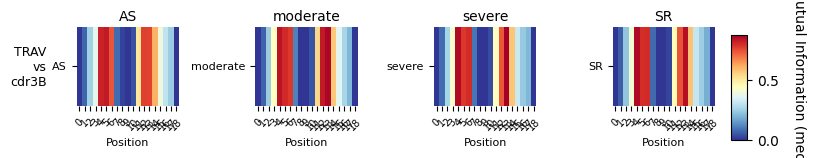

In [105]:
pair_sample_data = create_sample_grid_position_mi_heatmap('/mnt/d/TCRMI/results/covid/amino/cohort_ORF3a/pos_mi.pickle', 
                  '/mnt/d/TCRMI/results/covid/amino/cohort_ORF3a.pickle', 
                  save_dir=None, selected_features=[('TRAV', 'cdr3B')])

In [102]:
def create_cdr3_position_mi_heatmap(mi_path, samples_path, save_dir=None, 
                                   statistic='median', samples_per_row=6, 
                                   figsize_per_heatmap=(3, 2.5)):
    """
    Create a grid of heatmaps for CDR3A vs CDR3B position-wise MI.
    Each heatmap shows the MI between CDR3α and CDR3β positions for one sample.
    Matrix shape for each sample: (cdr3alpha_length, cdr3beta_length)
    
    Parameters:
    -----------
    mi_path : str
        Path to MI results pickle file
    samples_path : str  
        Path to samples data pickle file
    save_dir : str
        Directory to save figures
    statistic : str
        Statistic to use ('mean', 'median', 'max')
    samples_per_row : int
        Number of samples (heatmaps) per row
    figsize_per_heatmap : tuple
        Size of each individual heatmap (width, height)
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    sample_ids = list(data_dict.keys())
    
    # Get CDR3A vs CDR3B MI data
    feature_pair = ('cdr3A', 'cdr3B')
    if feature_pair not in mi or 'position_results' not in mi[feature_pair]:
        print("CDR3A vs CDR3B position results not found in MI data")
        return
    
    position_results = mi[feature_pair]['position_results']
    n_bootstrap = len(list(position_results.values())[0])
    
    print(f"Found {len(sample_ids)} samples")
    print(f"Found {n_bootstrap} bootstrap iterations")
    
    # Calculate layout
    n_samples = len(sample_ids)
    n_cols = min(samples_per_row, n_samples)
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    # Calculate figure size
    fig_width = n_cols * figsize_per_heatmap[0]
    fig_height = n_rows * figsize_per_heatmap[1]
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    
    # Handle edge cases for axes indexing - this is the key fix
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    else:
        # axes is already in the correct shape (n_rows, n_cols)
        pass
    
    # Store all matrices for consistent color scaling
    all_matrices = []
    sample_data = {}
    
    print("Processing CDR3 data for each sample...")
    
    # Process each sample
    for sample_id in sample_ids:
        
        alpha_length = 19
        beta_length = 19
        
        # Create position-position MI matrix for this sample
        sample_matrix = np.zeros((alpha_length, beta_length))
        
        # Fill matrix with MI values
        for i in range(alpha_length):
            for j in range(beta_length):
                
                pos_key = f'pos_{i}_{j}'
                if pos_key in position_results:
                    bootstrap_values = []
                    
                    for bootstrap_idx in range(n_bootstrap):
                        bootstrap_data = position_results[pos_key][bootstrap_idx]
                        if sample_id in bootstrap_data:
                            bootstrap_values.append(bootstrap_data[sample_id])
                    
                    if bootstrap_values:
                        if statistic == 'mean':
                            sample_matrix[i, j] = np.mean(bootstrap_values)
                        elif statistic == 'median':
                            sample_matrix[i, j] = np.median(bootstrap_values)
                        elif statistic == 'max':
                            sample_matrix[i, j] = np.max(bootstrap_values)
                        else:
                            sample_matrix[i, j] = np.mean(bootstrap_values)
        
        sample_data[sample_id] = {
            'matrix': sample_matrix,
            'alpha_length': alpha_length,
            'beta_length': beta_length
        }
        all_matrices.append(sample_matrix)
    
    # Calculate global min/max for consistent color scaling across all heatmaps
    if all_matrices:
        global_min = min(matrix.min() for matrix in all_matrices)
        global_max = max(matrix.max() for matrix in all_matrices)
    else:
        global_min, global_max = 0, 1
    
    print(f"Global MI range: {global_min:.4f} to {global_max:.4f}")
    
    # Create heatmaps in the same figure
    print("Creating heatmaps...")
    
    for sample_idx, sample_id in enumerate(sample_ids):
        # Calculate subplot position
        row = sample_idx // n_cols
        col = sample_idx % n_cols
        
        # Get the correct axis - this is the corrected part
        ax = axes[row, col]
        
        # Get sample data
        data = sample_data[sample_id]
        matrix = data['matrix']
        alpha_length = data['alpha_length']
        beta_length = data['beta_length']
        
        # Create position labels
        x_labels = [str(i) for i in range(beta_length)]
        y_labels = [str(i) for i in range(alpha_length)]
        
        # Create heatmap
        sns.heatmap(matrix,
                   xticklabels=x_labels,
                   yticklabels=y_labels,
                   annot=False,
                   cmap='RdYlBu_r',
                   vmin=global_min,
                   vmax=global_max,
                   cbar=False,  # We'll add a single colorbar later
                   square=True,
                   ax=ax)
        
        # Set title for each heatmap
        ax.set_title(f'{sample_id}', fontsize=10, pad=5)
        
        # Set labels
        ax.set_xlabel('CDR3β positions', fontsize=8)
        ax.set_ylabel('CDR3α positions', fontsize=8)
        
        # Adjust tick parameters
        ax.tick_params(axis='x', rotation=0, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)
        
        print(f"  Created heatmap for sample {sample_id}")
    
    # Hide unused subplots
    for sample_idx in range(n_samples, n_rows * n_cols):
        row = sample_idx // n_cols
        col = sample_idx % n_cols
        ax = axes[row, col]
        ax.set_visible(False)
    
    # Add a single colorbar for the entire figure
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', 
                              norm=plt.Normalize(vmin=global_min, vmax=global_max))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(f'Mutual Information ({statistic})', rotation=270, labelpad=20, fontsize=10)
    
    # Add main title for the entire figure
    # fig.suptitle(f'CDR3α-CDR3β Position-wise Mutual Information ({statistic})', 
    #             fontsize=14, y=0.95)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.subplots_adjust(right=0.9, top=0.9)
    
    # Save figure
    if save_dir:
        import os
        os.makedirs(save_dir, exist_ok=True)
        save_path = f"{save_dir}/cdr3_position_mi_{statistic}.pdf"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved CDR3 position MI heatmap: {save_path}")
    
    # Show the figure
    plt.show()
    
    # Return the processed data for further analysis
    return sample_data

Found 4 samples
Found 50 bootstrap iterations
Processing CDR3 data for each sample...
Global MI range: -0.0021 to 0.5259
Creating heatmaps...
  Created heatmap for sample AS
  Created heatmap for sample moderate
  Created heatmap for sample severe
  Created heatmap for sample SR


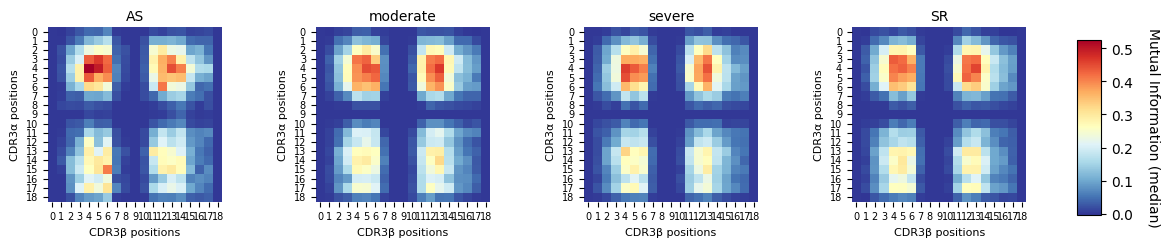

In [103]:
pair_sample_data = create_cdr3_position_mi_heatmap('/mnt/d/TCRMI/results/covid/amino/cohort_ORF3a/pos_mi.pickle', 
                  '/mnt/d/TCRMI/results/covid/amino/cohort_ORF3a.pickle', 
                  save_dir=None)